<a href="https://colab.research.google.com/github/joyashre/LLM-NLP-Learning-task/blob/main/NLP_Task_4_%26_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # task 4

 # POS (Part-of-Speech) tagging

In [ ]:
# Cell 1: Install NLTK and download required datasets
import nltk

print("Downloading required NLTK datasets...")
nltk.download('treebank')
nltk.download('universal_tagset')
nltk.download('punkt')
nltk.download('punkt_tab')
print("Downloads complete!")

# Load a sample sentence to test our taggers
sample_sentence = "The intelligent student is coding a new algorithm quickly."
tokens = nltk.word_tokenize(sample_sentence)
print(f"Sample Tokens: {tokens}")

[nltk_data] Downloading package treebank to /root/nltk_data...
[nltk_data]   Package treebank is already up-to-date!
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Downloads complete!
Sample Tokens: ['The', 'intelligent', 'student', 'is', 'coding', 'a', 'new', 'algorithm', 'quickly', '.']


## (A) Rule-based method

In [ ]:
# Cell 2: Rule-Based POS Tagger using Regular Expressions
import nltk
from nltk.tag import RegexpTagger

# Define rules using Regular Expressions
# Format: (Regex_Pattern, POS_Tag)
patterns = [
    (r'.*ing$', 'VBG'),               # gerunds (e.g., coding, running)
    (r'.*ed$', 'VBD'),                # simple past (e.g., tested, played)
    (r'.*es$', 'VBZ'),                # 3rd singular present (e.g., does, goes)
    (r'.*ould$', 'MD'),               # modals (e.g., would, could)
    (r'.*\'s$', 'NN$'),               # possessive nouns (e.g., student's)
    (r'.*s$', 'NNS'),                 # plural nouns (e.g., algorithms, students)
    (r'^-?[0-9]+(.[0-9]+)?$', 'CD'),  # cardinal numbers (e.g., 10, 3.14)
    (r'.*ly$', 'RB'),                 # adverbs (e.g., quickly, slowly)
    (r'The|the|A|a|An|an$', 'DT'),    # articles/determiners
    (r'.*', 'NN')                     # Default fallback tag (Noun)
]

# Create the Rule-Based Tagger
rule_based_tagger = RegexpTagger(patterns)

# Test the tagger on our sample sentence
print("--- Rule-Based POS Tagging Results ---")
rule_based_tags = rule_based_tagger.tag(tokens)
for word, tag in rule_based_tags:
    print(f"{word:15} -> {tag}")

--- Rule-Based POS Tagging Results ---
The             -> DT
intelligent     -> NN
student         -> NN
is              -> NNS
coding          -> VBG
a               -> DT
new             -> NN
algorithm       -> DT
quickly         -> RB
.               -> NN


## Cell 3: (B) N-Gram Language Modelling

In [ ]:
# Cell 3: N-Gram POS Tagger
import nltk
from nltk.corpus import treebank

print("Preparing data for N-gram training...")
# Load tagged sentences from the Penn Treebank corpus using universal tags (NOUN, VERB, etc.)
tagged_sentences = treebank.tagged_sents(tagset='universal')

# Split data into train (80%) and test (20%) sets
train_size = int(len(tagged_sentences) * 0.8)
train_sents = tagged_sentences[:train_size]
test_sents = tagged_sentences[train_size:]

print(f"Training on {len(train_sents)} sentences...")

# Train a Default Tagger (baseline)
default_tagger = nltk.DefaultTagger('NOUN')

# Train a Unigram Tagger (uses DefaultTagger as backoff)
unigram_tagger = nltk.UnigramTagger(train_sents, backoff=default_tagger)

# Train a Bigram Tagger (uses UnigramTagger as backoff)
# This looks at the current word and the tag of the previous word
bigram_tagger = nltk.BigramTagger(train_sents, backoff=unigram_tagger)

print("Training complete!\n")

# Test the N-gram tagger on our custom sample sentence
print("--- N-Gram POS Tagging Results ---")
ngram_tags = bigram_tagger.tag(tokens)
for word, tag in ngram_tags:
    print(f"{word:15} -> {tag}")

print("\n--- Model Evaluation ---")
# Evaluate the accuracy of our N-gram tagger on the unseen test dataset
accuracy = bigram_tagger.evaluate(test_sents)
print(f"Accuracy on unseen test data: {accuracy:.2%}")

Preparing data for N-gram training...
Training on 3131 sentences...
Training complete!

--- N-Gram POS Tagging Results ---
The             -> DET
intelligent     -> NOUN
student         -> NOUN
is              -> VERB
coding          -> NOUN
a               -> DET
new             -> ADJ
algorithm       -> NOUN
quickly         -> ADV
.               -> .

--- Model Evaluation ---


/tmp/ipykernel_23245/1454518696.py:36: DeprecationWarning: 
  Function evaluate() has been deprecated.  Use accuracy(gold)
  instead.
  accuracy = bigram_tagger.evaluate(test_sents)


Accuracy on unseen test data: 93.68%


# Task 5

In [ ]:
!pip install svgling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 3.3 MB/s eta 0:00:00


In [ ]:
# Cell: Context-Free Grammar for Bengali
import nltk
from IPython.display import display

In [ ]:
# 1. Define the Context-Free Grammar (CFG) for Bengali
# S = Sentence, NP = Noun Phrase, VP = Verb Phrase, Pro = Pronoun
bengali_cfg = nltk.CFG.fromstring("""
  S -> NP VP
  NP -> Pro
  VP -> Noun Verb
  Pro -> 'আমি'
  Noun -> 'ভাত'
  Verb -> 'খাই'
""")

In [ ]:
# 2. Create a Chart Parser using our grammar
parser = nltk.ChartParser(bengali_cfg)

# 3. Define the sentence and split it into tokens
# Sentence: "আমি ভাত খাই" (Ami bhat khai)
sentence = "আমি ভাত খাই"
tokens = sentence.split()

print(f"Sentence: {sentence}\n")

Sentence: আমি ভাত খাই



--- Text/ASCII Tree ---
     S           
  ___|____        
 NP       VP     
 |    ____|___    
Pro Noun     Verb
 |   |        |   
আমি ভাত      খাই 


--- Graphical Parse Tree ---


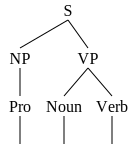

In [ ]:
# 4. Parse the sentence and draw the trees
try:
    # Parsing the tokens based on the grammar
    for tree in parser.parse(tokens):

        # Text-based ASCII tree for the console
        print("--- Text/ASCII Tree ---")
        tree.pretty_print()

        # Rich graphical tree using svgling
        print("\n--- Graphical Parse Tree ---")
        display(tree)

except ValueError as e:
    print(f"Grammar Error: {e}")

Sentence: বুদ্ধিমান ছাত্রটি দ্রুত একটি নতুন কোড লিখছে

--- Text/ASCII Tree ---
                             S                  
            _________________|____               
           |                      VP            
           |             _________|__________    
           NP           |         NP         |  
     ______|_____       |     ____|____      |   
   Adj          Noun   Adv  Det  Adj  Noun  Verb
    |            |      |    |    |    |     |   
বুদ্ধিমান     ছাত্রটি দ্রুত একটি নতুন কোড  লিখছে


--- Graphical Parse Tree ---


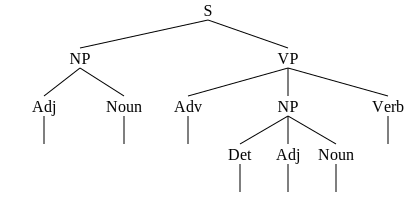

In [ ]:
bengali_cfg_complex = nltk.CFG.fromstring("""
  S -> NP VP
  NP -> Adj Noun | Det Adj Noun
  VP -> Adv NP Verb
  Adj -> 'বুদ্ধিমান' | 'নতুন'
  Noun -> 'ছাত্রটি' | 'কোড'
  Adv -> 'দ্রুত'
  Det -> 'একটি'
  Verb -> 'লিখছে'
""")

# 2. Create the parser
parser = nltk.ChartParser(bengali_cfg_complex)

# 3. The complex sentence
sentence = "বুদ্ধিমান ছাত্রটি দ্রুত একটি নতুন কোড লিখছে"
tokens = sentence.split()

print(f"Sentence: {sentence}\n")

# 4. Parse and display
try:
    for tree in parser.parse(tokens):

        print("--- Text/ASCII Tree ---")
        tree.pretty_print()

        print("\n--- Graphical Parse Tree ---")
        # Yeh command ek bada aur sundar graphical tree draw karegi
        display(tree)

except ValueError as e:
    print(f"Grammar Error: {e}")